In [2]:
# import TM_catalyst_framework.metal_template as template
# import the package
import os # package for reading, creating and saving files or directories
from TM_catalyst_framework import Template, Complex, Ligand, GeoOpt, QChem
from rdkit import Chem
from rdkit.Chem.EnumerateStereoisomers import EnumerateStereoisomers, StereoEnumerationOptions
Template().options()



tetrahedral
octahedral
trigonal_planar
square_pyramidal
trigonal_bipyramidal


/Users/dawn_mao/Desktop/PhD_research/chpt4_Ti_ureate/TM_catalyst_framework/src/TM_catalyst_framework/complex.py:240: SyntaxWarning: "\[" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\["? A raw string is also an option.
  ligand_smiles: str = "CC(C1=CC=CC=C1)N(/C(N(C2=C(C=CC=C2C)C)[*])=O\[*])C",


In [3]:
# Function to generate all monodentate ureate ligand isomers
def generate_all_monodentate_ureate_ligand(gen_ORCA_save_dir, 
                                           R_groups):
    all_ligand_isomers = []
    ureate_d1_core1_smiles = "[*:12][N]([*:13])C(O[*:2])=[N][*:11]"

    # initalize the ligand module
    ligand = Ligand()
    # Ligand function to attach R groups to core
    ureate_ligand_smiles = ligand.attach_R_group(core_smiles=ureate_d1_core1_smiles, R_smiles_ls=R_groups)

    
    # ------------------------------------------------------------------------------
    # Generate general ureate ligand molecule via RDKit
    m = Chem.MolFromSmiles(ureate_ligand_smiles)
    # Enumerate stereoisomers
    isomers = tuple(EnumerateStereoisomers(m, options=StereoEnumerationOptions(maxIsomers=1024)))
    # print(f"Number of stereoisomers: {len(isomers)}")

    for i, isomer in enumerate(isomers):
        isomer_smiles = Chem.MolToSmiles(isomer)
        # print(f"Stereoisomer {i + 1}: {isomer_smiles}")
        all_ligand_isomers.append(isomer_smiles)
    # ------------------------------------------------------------------------------
    print (len(all_ligand_isomers))

    ureate_d1_core2_smiles = "[*:12][N+]([*:13])=C(O[*:2])[N-][*:11]"

    ligand = Ligand()
    ureate_ligand_smiles = ligand.attach_R_group(core_smiles=ureate_d1_core2_smiles, R_smiles_ls=R_groups)
    
    # ------------------------------------------------------------------------------
    # Generate general ureate ligand molecule via RDKit
    m = Chem.MolFromSmiles(ureate_ligand_smiles)
    # Enumerate stereoisomers
    isomers = tuple(EnumerateStereoisomers(m, options=StereoEnumerationOptions(maxIsomers=1024)))
    # print(f"Number of stereoisomers: {len(isomers)}")

    for i, isomer in enumerate(isomers):
        isomer_smiles = Chem.MolToSmiles(isomer)
        # print(f"Stereoisomer {i + 1}: {isomer_smiles}")
        all_ligand_isomers.append(isomer_smiles)
    print (len(all_ligand_isomers))

    return all_ligand_isomers

In [4]:
gen_ORCA_save_dir = "./L1_ORCA_files/"
if not os.path.exists(gen_ORCA_save_dir):
    os.makedirs(gen_ORCA_save_dir)

R1_smiles = "[*:11]C1=C(C(C)C)C=CC=C1C(C)C" 
R2_smiles = "[*:12]C"
R3_smiles = "CC([*:13])C1=CC=CC=C1"
R_groups = [R1_smiles, R2_smiles, R3_smiles]
monodentate_ligand_isomers = generate_all_monodentate_ureate_ligand(gen_ORCA_save_dir, R_groups=R_groups)

[*:12][N]([*:13])C(O[*:2])=[N][*:11].[*:11]C1=C(C(C)C)C=CC=C1C(C)C.[*:12]C.CC([*:13])C1=CC=CC=C1
4
[*:12][N+]([*:13])=C(O[*:2])[N-][*:11].[*:11]C1=C(C(C)C)C=CC=C1C(C)C.[*:12]C.CC([*:13])C1=CC=CC=C1
8


[12:28:19] Incomplete atom labelling, cannot make bond
[12:28:19] Incomplete atom labelling, cannot make bond


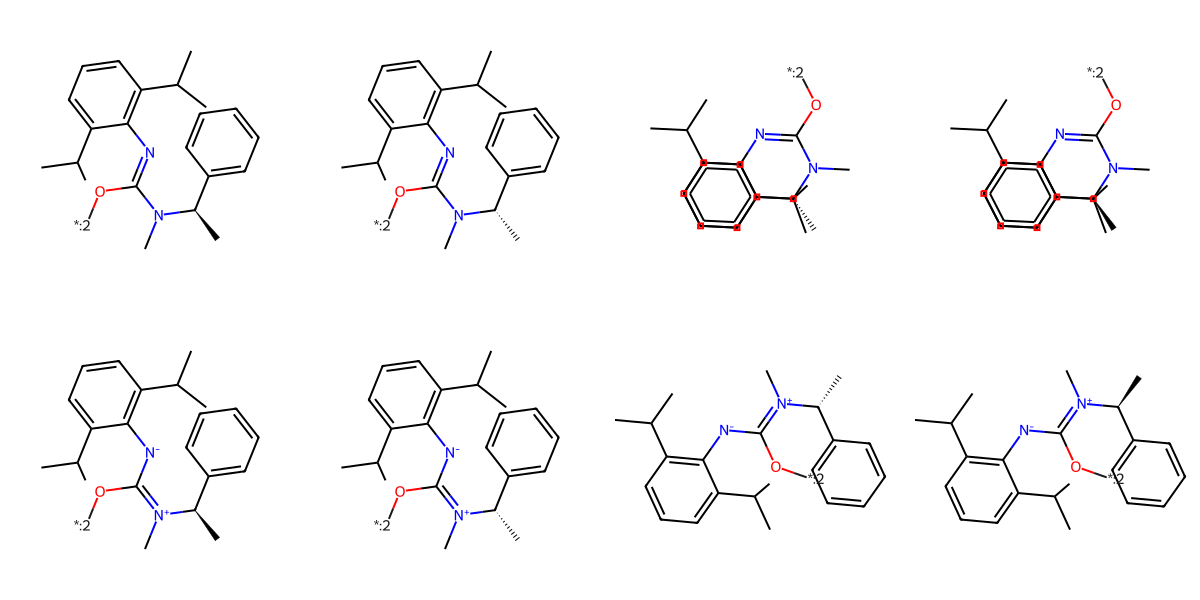

In [5]:
from rdkit import Chem
from rdkit.Chem import Draw
mols = [Chem.MolFromSmiles(s) for s in monodentate_ligand_isomers]
img = Draw.MolsToGridImage(
    mols,
    molsPerRow=4,
    subImgSize=(300, 300) # Optional: adjust image size per molecule
)
img

In [6]:
monodentate_ligand_isomers

['CC(C)c1cccc(C(C)C)c1/N=C(\\O[*:2])N(C)[C@H](C)c1ccccc1',
 'CC(C)c1cccc(C(C)C)c1/N=C(\\O[*:2])N(C)[C@@H](C)c1ccccc1',
 'CC(C)c1cccc(C(C)C)c1/N=C(/O[*:2])N(C)[C@H](C)c1ccccc1',
 'CC(C)c1cccc(C(C)C)c1/N=C(/O[*:2])N(C)[C@@H](C)c1ccccc1',
 'CC(C)c1cccc(C(C)C)c1[N-]/C(O[*:2])=[N+](/C)[C@H](C)c1ccccc1',
 'CC(C)c1cccc(C(C)C)c1[N-]/C(O[*:2])=[N+](/C)[C@@H](C)c1ccccc1',
 'CC(C)c1cccc(C(C)C)c1[N-]/C(O[*:2])=[N+](\\C)[C@H](C)c1ccccc1',
 'CC(C)c1cccc(C(C)C)c1[N-]/C(O[*:2])=[N+](\\C)[C@@H](C)c1ccccc1']

In [6]:
def generate_all_bidentate_ureate_ligand(gen_ORCA_save_dir, R_groups):
    
    ureate_d2_core1_smiles = "[*:13]N(C(O[*:2])=[N+]([*:1])[*:11])[*:12]"
    all_ligand_isomers = []
    ligand = Ligand()
    ureate_ligand_smiles = ligand.attach_R_group(core_smiles=ureate_d2_core1_smiles, R_smiles_ls=R_groups)

    from rdkit import Chem
    from rdkit.Chem.EnumerateStereoisomers import EnumerateStereoisomers, StereoEnumerationOptions
    # ------------------------------------------------------------------------------
    # Generate general ureate ligand molecule via RDKit
    m = Chem.MolFromSmiles(ureate_ligand_smiles)
    # Enumerate stereoisomers
    isomers = tuple(EnumerateStereoisomers(m, options=StereoEnumerationOptions(maxIsomers=1024)))
    # print(f"Number of stereoisomers: {len(isomers)}")

    for i, isomer in enumerate(isomers):
        isomer_smiles = Chem.MolToSmiles(isomer)
        # print(f"Stereoisomer {i + 1}: {isomer_smiles}")
        all_ligand_isomers.append(isomer_smiles)
    print (len(all_ligand_isomers))



    ureate_d2_core2_smiles = "[*:13][N+](C(O[*:2])=[N][*:11])([*:1])[*:12]"

    ligand = Ligand()
    ureate_ligand_smiles = ligand.attach_R_group(core_smiles=ureate_d2_core2_smiles, R_smiles_ls=R_groups)

    from rdkit import Chem
    from rdkit.Chem.EnumerateStereoisomers import EnumerateStereoisomers, StereoEnumerationOptions
    # ------------------------------------------------------------------------------
    # Generate general ureate ligand molecule via RDKit
    m = Chem.MolFromSmiles(ureate_ligand_smiles)
    # Enumerate stereoisomers
    isomers = tuple(EnumerateStereoisomers(m, options=StereoEnumerationOptions(maxIsomers=1024)))
    # print(f"Number of stereoisomers: {len(isomers)}")

    for i, isomer in enumerate(isomers):
        isomer_smiles = Chem.MolToSmiles(isomer)
        # print(f"Stereoisomer {i + 1}: {isomer_smiles}")
        all_ligand_isomers.append(isomer_smiles)
    print (len(all_ligand_isomers))

    # print (f"Total number of d2 ureate ligand isomers: {len(all_ligand_isomers)}")
    return all_ligand_isomers

all_bidentate_ligand_isomers = generate_all_bidentate_ureate_ligand(gen_ORCA_save_dir, R_groups)


[*:13]N(C(O[*:2])=[N+]([*:1])[*:11])[*:12].[*:11]C1=C(C(C)C)C=CC=C1C(C)C.[*:12]C.CC([*:13])C1=CC=CC=C1
4
[*:13][N+](C(O[*:2])=[N][*:11])([*:1])[*:12].[*:11]C1=C(C(C)C)C=CC=C1C(C)C.[*:12]C.CC([*:13])C1=CC=CC=C1
12


[23:34:42] Incomplete atom labelling, cannot make bond
[23:34:42] Incomplete atom labelling, cannot make bond
[23:34:42] Incomplete atom labelling, cannot make bond
[23:34:42] Incomplete atom labelling, cannot make bond


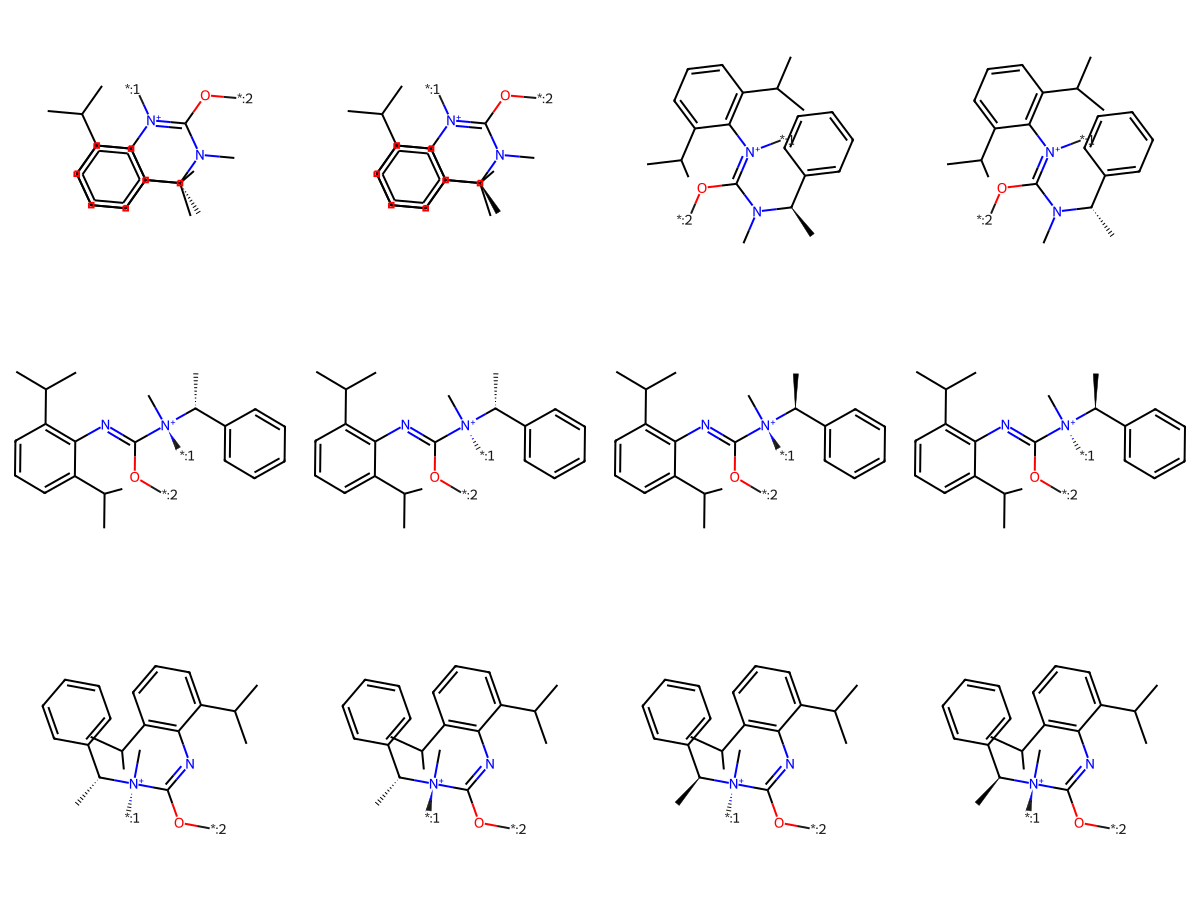

In [7]:
mols = [Chem.MolFromSmiles(s) for s in all_bidentate_ligand_isomers]
img = Draw.MolsToGridImage(
    mols,
    molsPerRow=4,
    subImgSize=(300, 300) # Optional: adjust image size per molecule
)
img

In [8]:
from TM_catalyst_framework.complex import Mapping
ORCA_save_dir = os.path.join(gen_ORCA_save_dir, f"d1_iso/")
if not os.path.exists(ORCA_save_dir):
    os.makedirs(ORCA_save_dir)

precursor_ligand_smiles = "*N(C)C"
metal_ligand_attach_scheme = Mapping(attach_scheme = {})
# Define precursor ligand SMILES
# Define precursor ligand attachment scheme
for site_i in range(1, 4):
    print ("Adding precursor ligand at coordination site:", site_i)
    metal_ligand_attach_scheme.add_monodentate(ligand_SMILES=precursor_ligand_smiles,
                                                coordination_site = site_i)
ureate_d1_ligand_smiles = monodentate_ligand_isomers[0]
metal_ligand_attach_scheme.add_monodentate(ligand_SMILES=ureate_d1_ligand_smiles,
                                                        coordination_site = 4)

print (metal_ligand_attach_scheme.to_dict())


Adding precursor ligand at coordination site: 1
Adding precursor ligand at coordination site: 2
Adding precursor ligand at coordination site: 3
{1: ['*N(C)C', 1], 2: ['*N(C)C', 2], 3: ['*N(C)C', 3], 4: ['CC(C)c1cccc(C(C)C)c1/N=C(\\O[*:2])N(C)[C@H](C)c1ccccc1', 4]}


In [9]:
# set up force field optimization parameters
force_field_steps = 2000
force_field_method = "uff" # options: ghemical, uff, mmff94; however uff is the most stable
# Generate the complex geometry and save to file
create_complex = Complex(metal_center="Ti", # define the metal center identity, e.g. titanium
                        force_field = force_field_method, # default: uff, options: ghemical, uff, mmff94; however uff is the most stable
                        force_field_steps = force_field_steps # optional
                        )


# set up computational parameters for QChem
nprocs = 8
maxcore = 14000

# Create the geometry
ff_energy = 3001 # initialize the ff_energy threshold
sdf_filename = f"{ORCA_save_dir}initial_geometry"
print (sdf_filename)
while ff_energy > 3000:
    create_complex.generate_complex(geometry = "tetrahedral",
                                        output_filename=sdf_filename,
                                        output_format= "sdf",
                                        attach_scheme= metal_ligand_attach_scheme.attach_scheme,
                                        )
    ff_energy = create_complex.ff_energy
    print (f"Final FF energy is {ff_energy} kcal/mol")
print ("==================== Complex generation completed ====================")


./L1_ORCA_files/d1_iso/initial_geometry
True
Molecule with 5 atoms
Final ligand energy: 2.47 kcal/mol
Running constrained optimization...
Running constrained optimization...
Final ligand energy: 2.47 kcal/mol
Running constrained optimization...


[23:34:43] UFFTYPER: Unrecognized atom type: *_ (0)
[23:34:43] UFFTYPER: Unrecognized atom type: *_ (0)
*** Open Babel Warning  in Expand
  Alias R was not chemically interpreted

[23:34:43] UFFTYPER: Unrecognized atom type: *_ (0)
[23:34:43] UFFTYPER: Unrecognized atom type: *_ (0)
[23:34:43] UFFTYPER: Unrecognized atom type: *_ (0)
[23:34:43] UFFTYPER: Unrecognized atom type: *_ (0)


Running constrained optimization...
Final ligand energy: 2.47 kcal/mol
Running constrained optimization...
Running constrained optimization...


[23:34:44] UFFTYPER: Unrecognized atom type: *_ (15)
[23:34:44] UFFTYPER: Unrecognized atom type: *_ (15)
*** Open Babel Warning  in Expand
  Alias R was not chemically interpreted



Final ligand energy: 54.71 kcal/mol
Running constrained optimization...
Running constrained optimization...
Running constrained optimization...
Running constrained optimization...
Final FF energy is 1831.7312723061923 kcal/mol
==================== Complex generation completed ====================


In [10]:
from TM_catalyst_framework.io_utils import mol_visual
import openbabel.openbabel as ob
from openbabel import pybel

mol_3d = mol_visual.visualize_mol_molecule(create_complex.complex)
mol_3d

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

mol provided is invalid: in method 'OBConversion_WriteString', argument 2 of type 'OpenBabel::OBBase *'
Additional information:
Wrong number or type of arguments for overloaded function 'OBConversion_WriteString'.
  Possible C/C++ prototypes are:
    OpenBabel::OBConversion::WriteString(OpenBabel::OBBase *,bool)
    OpenBabel::OBConversion::WriteString(OpenBabel::OBBase *)
, try passing in a valid RDKit or OpenBabel mol object


In [11]:
from openbabel import pybel

# Using the ORCA python interface package to generate input files
from opi.core import Calculator
from opi.input.structures.structure import Structure
from opi.input.simple_keywords import Approximation, Dft, Task, BasisSet, AuxBasisSet, Scf, DispersionCorrection
from opi.input.blocks.base import Block

# Function to generate SLURM script
def generate_slurm_script(account_name: str = "def-rkrems", # Replace with your actual SLURM account
        molecule_name: str = "ti_d2d2_iso1", # Name of your molecule/system (used in file names)
        ntasks: int = 8, # Number of CPUs (should match %pal nprocs in ORCA input)
        memory: int = 16000,  # Memory per CPU in MB (e.g., 3800M)
        days: int = 00,  # Days for walltime (format as two digits if needed)
        hours: int = 10,   # Hours for walltime (00-23, format as two digits)
        minutes: int = 00, # Minutes for walltime (00-59, format as two digits)
        orca_inp_filename: str = "orca", # ORCA input filename
        script_filename: str = f"run_orca.sh" # Optional: customize the output .sh filename
    ): 
    """
    Generate a SLURM submission script for an ORCA job.
    Parameters:
    - account_name (str): SLURM account name.
    - molecule_name (str): Name of the molecule/system (used in file names).
    - ntasks (int): Number of CPUs (should match nprocs in ORCA input).
    - memory (int): Memory per CPU in MB.
    - days (int): Days for walltime.
    - hours (int): Hours for walltime.
    - orca_inp_filename (str): ORCA input filename (without extension).
    - script_filename (str): Output SLURM script filename.
    """
    lines = (
        f"#!/bin/bash\n"
        f"#SBATCH --job-name={molecule_name}\n"
        f"#SBATCH --account={account_name}\n"
        f"#SBATCH --ntasks={ntasks}               # cpus, should match nprocs in ORCA input\n"
        f"#SBATCH --mem-per-cpu={memory}M         # memory per cpu\n"
        f"#SBATCH --time={days}-{hours}:{minutes}         # time limit (DD-HH:MM)\n"
        f"#SBATCH --output={molecule_name}.log    # standard output\n"
        f"#SBATCH --error={molecule_name}.err     # standard error\n\n"
        f"module load StdEnv/2023 gcc/12.3 openmpi/4.1.5 orca/6.0.1\n\n"
        f"$EBROOTORCA/orca {orca_inp_filename}.inp > {orca_inp_filename}.out\n"
    )

    # Write the script to file
    with open(script_filename, "w") as f:
            for line in lines:
                f.write(line)
    # print(f"SLURM script successfully written to: {script_filename}")
    # print("You can now submit it with: sbatch " + script_filename)
# Function to generate ORCA input files for geometry optimization restart
def generate_files(sdf_filename,
                   mol,
                   ORCA_save_dir,
                   iso_name
                   ):
        GeoOpt_util = GeoOpt(force_field="uff",
                        force_field_steps=5000,
                        ff_convergence=1.0e-4,
                        metal_center="Ti")

        GeoOpt_util.fix_overlapping_atoms(filename=str(f"{sdf_filename}.sdf"), delta=0.1)
        mol = pybel.readfile("sdf", f"{sdf_filename}.sdf").__next__()
        # print ("saving xyz file for orca restart...")
        # print (f"XYZ file save directory: {sdf_filename}.xyz")
        mol.write("xyz", f"{sdf_filename}.xyz", overwrite=True)
        mol.write("sdf", f"{sdf_filename}.sdf", overwrite=True)


        # Load the previous geometry
        structure = Structure.from_xyz(f"{sdf_filename}.xyz")
        # from_xyz(xyz_block)

        # Set up the calculator for restarting the optimization
        calc = Calculator(
        basename="orca", working_dir = ORCA_save_dir,
        )
        calc.json_via_input = False
        calc.structure = structure

        # Add keywords
        calc.input.add_simple_keywords(
        [Approximation.RIJCOSX,
        Dft.B3PW91,
        BasisSet.DEF2_SV_P,
        AuxBasisSet.DEF2_J,
        DispersionCorrection.D3BJ,
        Task.OPT,
        Scf.TIGHTSCF
        ]
        )

        calc.input.ncores = nprocs
        calc.input.memory = maxcore

        # Write the input files
        calc.write_input()

        # print(f"Restart ORCA input file generated: {ORCA_save_dir}/orca.inp")
        # print("Copy previous .gbw and .xyz files to the run directory if needed.")
        # print("Submit as usual with your SLURM script.")

        generate_slurm_script(
                molecule_name=iso_name,
                ntasks=nprocs,
                memory=maxcore,
                orca_inp_filename="orca",
                days=3,
                script_filename=f"{ORCA_save_dir}/run_orca.sh"
                )

In [12]:
# Generate ORCA input files
sdf_filename = f"{ORCA_save_dir}initial_geometry"
iso_name = "ti_d1_iso1"
generate_files(sdf_filename, create_complex.complex, ORCA_save_dir, iso_name)
mol = pybel.readfile("sdf", f"{sdf_filename}.sdf").__next__()
mol_3d = mol_visual.visualize_mol_molecule(mol)
mol_3d

Overlapping atoms detected and perturbed:
  Atom 27 (H): z = 3.0023 → 3.0953 Å
  Atom 28 (H): z = 3.0023 → 2.8263 Å

Running geometry optimization to relax perturbed structure...
Running constrained optimization...
Geometry optimization complete.


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

mol provided is invalid: in method 'OBConversion_WriteString', argument 2 of type 'OpenBabel::OBBase *'
Additional information:
Wrong number or type of arguments for overloaded function 'OBConversion_WriteString'.
  Possible C/C++ prototypes are:
    OpenBabel::OBConversion::WriteString(OpenBabel::OBBase *,bool)
    OpenBabel::OBConversion::WriteString(OpenBabel::OBBase *)
, try passing in a valid RDKit or OpenBabel mol object


In [16]:

precursor_ligand_smiles = "*N(C)C"
metal_ligand_attach_scheme = Mapping(attach_scheme = {})
# Define precursor ligand SMILES
# Define precursor ligand attachment scheme
site_ls = [1,4]
for site_i in site_ls:
    print ("Adding precursor ligand at coordination site:", site_i)
    metal_ligand_attach_scheme.add_monodentate(ligand_SMILES=precursor_ligand_smiles,
                                                coordination_site = site_i)
# Define ureate ligand SMILES
ureate_smiles = all_bidentate_ligand_isomers[-2]
metal_ligand_attach_scheme.add_bidentate(ligand_SMILES=ureate_smiles,
                                                coordination_site_1 = 2,
                                                coordination_site_2 = 3)
metal_ligand_attach_scheme.add_bidentate(ligand_SMILES=ureate_smiles,
                                                coordination_site_1 = 5,
                                                coordination_site_2 = 6)
print (metal_ligand_attach_scheme.to_dict())

Adding precursor ligand at coordination site: 1
Adding precursor ligand at coordination site: 4
{1: ['*N(C)C', 1], 2: ['*N(C)C', 4], 3: ['CC(C)c1cccc(C(C)C)c1/N=C(/O[*:2])[N@+](C)([C@@H](C)c1ccccc1)[*:1]', [2, 3]], 4: ['CC(C)c1cccc(C(C)C)c1/N=C(/O[*:2])[N@+](C)([C@@H](C)c1ccccc1)[*:1]', [5, 6]]}


In [17]:
# --------------------------------------------------------------
# Generate the complex geometry and save to file
create_complex = Complex(metal_center="Ti", # must
                        force_field = "uff", # default: uff, options: ghemical, uff, mmff94
                        force_field_steps = force_field_steps    # optional
                        )
ff_energy = 8001
ORCA_save_dir = os.path.join(gen_ORCA_save_dir, f"d2d2_iso/")
if not os.path.exists(ORCA_save_dir):
    os.makedirs(ORCA_save_dir)
sdf_filename = f"{ORCA_save_dir}initial_geometry"
while ff_energy > 8000:
    # Create the geometry
    create_complex.generate_complex(geometry = "octahedral",
                                        output_filename=sdf_filename,
                                        output_format= "sdf",
                                        attach_scheme= metal_ligand_attach_scheme.attach_scheme,
                                        )
    ff_energy = create_complex.ff_energy
    print (f"Optimization energy: {ff_energy} kcal/mol")
print ("==================== Complex generation completed ====================")

True
Molecule with 7 atoms
Final ligand energy: 2.47 kcal/mol
Running constrained optimization...
Running constrained optimization...
Final ligand energy: 2.47 kcal/mol
Running constrained optimization...


[23:39:38] UFFTYPER: Unrecognized atom type: *_ (0)
[23:39:38] UFFTYPER: Unrecognized atom type: *_ (0)
*** Open Babel Warning  in Expand
  Alias R was not chemically interpreted

[23:39:38] UFFTYPER: Unrecognized atom type: *_ (0)
[23:39:38] UFFTYPER: Unrecognized atom type: *_ (0)
*** Open Babel Warning  in Expand
  Alias R was not chemically interpreted



Running constrained optimization...


[23:39:39] UFFTYPER: Unrecognized atom type: *_ (15)
[23:39:39] UFFTYPER: Unrecognized atom type: *_ (26)
[23:39:39] UFFTYPER: Unrecognized atom type: *_ (15)
[23:39:39] UFFTYPER: Unrecognized atom type: *_ (26)
*** Open Babel Warning  in Expand
  Alias R was not chemically interpreted



Final ligand energy: 75.00 kcal/mol
Running constrained optimization...
*
*
*
*
*
*
*
Running constrained optimization...
Final ligand energy: 75.00 kcal/mol
Running constrained optimization...


...

*
*
*
*
*
*
*
Running constrained optimization...
Running constrained optimization...
Running constrained optimization...
Optimization energy: 15458.813817988594 kcal/mol
True
Molecule with 7 atoms
Final ligand energy: 2.47 kcal/mol
Running constrained optimization...
Running constrained optimization...
Final ligand energy: 2.47 kcal/mol
Running constrained optimization...
Running constrained optimization...


[23:43:35] UFFTYPER: Unrecognized atom type: *_ (0)
[23:43:35] UFFTYPER: Unrecognized atom type: *_ (0)
*** Open Babel Warning  in Expand
  Alias R was not chemically interpreted

[23:43:35] UFFTYPER: Unrecognized atom type: *_ (0)
[23:43:35] UFFTYPER: Unrecognized atom type: *_ (0)
*** Open Babel Warning  in Expand
  Alias R was not chemically interpreted

[23:43:35] UFFTYPER: Unrecognized atom type: *_ (15)
[23:43:35] UFFTYPER: Unrecognized atom type: *_ (26)
[23:43:35] UFFTYPER: Unrecognized atom type: *_ (15)
[23:43:35] UFFTYPER: Unrecognized atom type: *_ (26)
*** Open Babel Warning  in Expand
  Alias R was not chemically interpreted



Final ligand energy: 66.52 kcal/mol
Running constrained optimization...
*
*
*
*
*
*
*
Running constrained optimization...
Final ligand energy: 60.99 kcal/mol
Running constrained optimization...


[23:43:37] UFFTYPER: Unrecognized atom type: *_ (15)
[23:43:37] UFFTYPER: Unrecognized atom type: *_ (26)
[23:43:37] UFFTYPER: Unrecognized atom type: *_ (15)
[23:43:37] UFFTYPER: Unrecognized atom type: *_ (26)
*** Open Babel Warning  in Expand
  Alias R was not chemically interpreted



*
*
*
*
*
*
*
Running constrained optimization...
Running constrained optimization...
Running constrained optimization...
Optimization energy: 5593.83716271735 kcal/mol
==================== Complex generation completed ====================


In [18]:
# Generate ORCA input files
sdf_filename = f"{ORCA_save_dir}initial_geometry"
iso_name = "ti_d2d2_iso1"
generate_files(sdf_filename, create_complex.complex, ORCA_save_dir, iso_name)
mol = pybel.readfile("sdf", f"{sdf_filename}.sdf").__next__()
mol_3d = mol_visual.visualize_mol_molecule(mol)
mol_3d

Overlapping atoms detected and perturbed:
  Atom 15 (H): z = -0.7595 → -0.8415 Å

Running geometry optimization to relax perturbed structure...
Running constrained optimization...
Geometry optimization complete.


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

mol provided is invalid: in method 'OBConversion_WriteString', argument 2 of type 'OpenBabel::OBBase *'
Additional information:
Wrong number or type of arguments for overloaded function 'OBConversion_WriteString'.
  Possible C/C++ prototypes are:
    OpenBabel::OBConversion::WriteString(OpenBabel::OBBase *,bool)
    OpenBabel::OBConversion::WriteString(OpenBabel::OBBase *)
, try passing in a valid RDKit or OpenBabel mol object
